# DataVine Analytics - ML Prototype Suite

As a junior data scientist at DataVine Analytics, this notebook develops three prototype 
machine learning solutions for different client sectors, using standardized datasets that 
mirror real world problems.

**Tools used across all three projects:** pandas, numpy, scikit-learn, matplotlib, seaborn

## Project 1: Wine Classification
Client: a premium wine distributor.
Business need: automatically classify wines by chemical properties, to support inventory 
management and quality control.
Approach: k-Nearest Neighbors with PCA, tuned through GridSearchCV.
Success looks like: a model accurate enough to trust for automated sorting, with an 
understanding of which wine types get confused with each other and why that matters 
operationally (for example, misclassifying two premium varieties is costlier than 
misclassifying two similarly priced ones).

## Project 2: Agricultural Recommendation Engine
Client: an agricultural supply company.
Business need: recommend similar feed types to farmers based on performance data, so a 
farmer considering one feed can be shown comparable alternatives.
Approach: PCA and cosine similarity on standardized chick weight data, using feed type 
as a proxy for product category.
Success looks like: recommendations that are defensible and explainable to a farmer, not 
just numerically similar.

## Project 3: Regional Crime Pattern Analysis
Client: a public policy research firm.
Business need: identify natural groupings in regional crime statistics to support 
resource allocation and policy decisions.
Approach: K-Means and Gaussian Mixture Models, with feature selection and PCA for 
dimensionality reduction.
Success looks like: clusters that map to something a policymaker could act on (for 
example, "high urban, high violent crime" states), not just a mathematically optimal 
cluster count.

In [1]:
%conda install -c conda-forge rdatasets -y
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.datasets import load_wine

from rdatasets import data

2 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.3.2
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


### Data Loading

In [2]:
# Dataset 1: Wine (for k-NN)
wine_data = load_wine()
wine_df = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
wine_df["target"] = wine_data.target

# Dataset 2: Chickwts (for Recommendation)
chickwts = data("chickwts").dropna()

# Dataset 3: USArrests (for Clustering)
usarrests = data("USArrests").dropna()

### Check for missing Values  and structure

In [3]:
for name, df in [("Wine", wine_df), ("Chickwts", chickwts), ("USArrests", usarrests)]:
    print(f"--- {name} ---")
    print(df.shape)
    print(df.isnull().sum())
    print(df.head(), "\n")

--- Wine ---
(178, 14)
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavano

### Standardizing numerical features

Each dataset has a different set of numeric feature columns (Wine's `target`, and 
Chickwts' `rownames`/`feed` are identifiers or labels, not features to scale). Below is 
a quick preview confirming standardization behaves as expected. 

Note: the scaling used here is for verification only. Each project later refits its own StandardScaler within 
its proper pipeline (for example, fit on training data only for Wine, to avoid data leakage).

In [4]:
wine_features = wine_df.drop(columns=["target"])
chickwts_numeric = chickwts[["weight"]]
usarrests_numeric = usarrests.drop(columns=["rownames"])

scaler_preview = StandardScaler()

for name, subset in [("Wine", wine_features), ("Chickwts", chickwts_numeric), ("USArrests", usarrests_numeric)]:
    scaled = scaler_preview.fit_transform(subset)
    print(f"--- {name} scaled preview ---")
    print(f"mean approx 0: {scaled.mean(axis=0).round(2)}")
    print(f"std approx 1: {scaled.std(axis=0).round(2)}\n")

--- Wine scaled preview ---
mean approx 0: [ 0.  0. -0. -0. -0. -0.  0. -0. -0. -0.  0.  0. -0.]
std approx 1: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

--- Chickwts scaled preview ---
mean approx 0: [-0.]
std approx 1: [1.]

--- USArrests scaled preview ---
mean approx 0: [-0.  0. -0.  0.]
std approx 1: [1. 1. 1. 1.]



### Interpreting the standardization check

All three datasets show means at approximately 0 and standard deviations at 
approximately 1 across every numeric feature. This confirms StandardScaler is working 
as expected: every feature is now on a comparable scale, regardless of its original 
units (for example, Wine's `proline`, originally in the hundreds, and `hue`, originally 
under 2, are now both centered and scaled the same way). This step is what makes 
distance-based methods like k-NN, PCA, and cosine similarity fair across features later on.

## Part 1: Wine Classification

### Exploratory Data Analysis
Before modeling, check class balance and feature relationships.

target
1    71
0    59
2    48
Name: count, dtype: int64


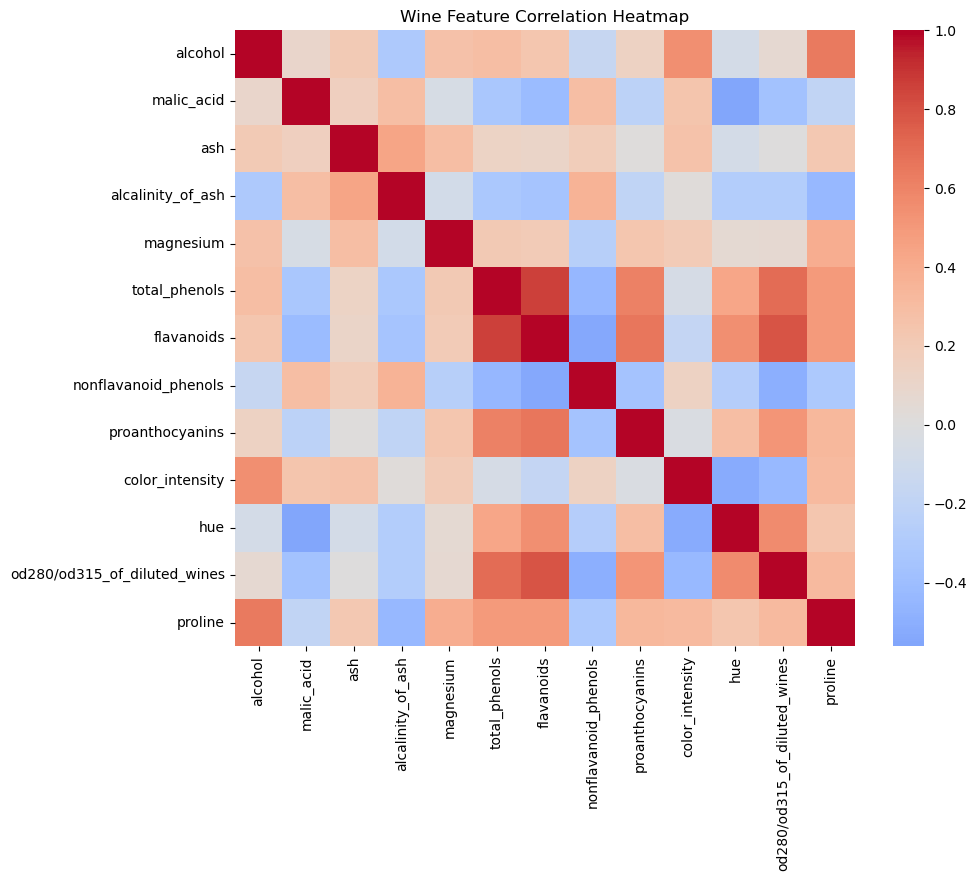

In [5]:
print(wine_df["target"].value_counts())

plt.figure(figsize=(10, 8))
sns.heatmap(wine_features.corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Wine Feature Correlation Heatmap")
plt.show()

### Interpreting the Wine feature correlations

A few patterns stand out:

- `total_phenols` and `flavanoids` are strongly positively correlated (dark red), as are 
  `flavanoids` and `od280/od315_of_diluted_wines`. This makes chemical sense, since these 
  three properties are all related to the wine's phenolic profile.
- `hue` and `malic_acid` show a notable negative correlation (blue), meaning wines with 
  higher acidity tend to have lower hue values.
- Most other feature pairs show weak correlation (pale colors near zero), suggesting the 
  13 features carry largely distinct information rather than being redundant with 
  each other.

This matters for PCA: features that are strongly correlated (like the phenol group) 
contribute overlapping information, meaning PCA can compress them into fewer components 
without losing much signal. Because most other features are only weakly correlated, PCA is 
unlikely to shrink the data drastically. Retaining 95 percent variance will likely still 
require a fair number of components, since there is genuine independent signal spread 
across most of the 13 features.

### Converting target labels to numeric values

`load_wine()` already provides target labels as integers (0, 1, 2), so there's nothing 
left to convert for modeling. To demonstrate the conversion step explicitly, I'm 
reconstructing the original string class names and running them through LabelEncoder, 
confirming it produces the same numeric labels already in the dataset.

In [6]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
wine_class_names = wine_data.target_names[wine_df["target"]]
encoded_target = label_encoder.fit_transform(wine_class_names)

print("Original class name sample:", wine_class_names[:5])
print("Encoded label sample:", encoded_target[:5])
print("Classes found by encoder:", label_encoder.classes_)
print("Matches existing target column:", (encoded_target == wine_df["target"].values).all())

Original class name sample: ['class_0' 'class_0' 'class_0' 'class_0' 'class_0']
Encoded label sample: [0 0 0 0 0]
Classes found by encoder: ['class_0' 'class_1' 'class_2']
Matches existing target column: True


This confirms the target labels were already properly numeric, and that LabelEncoder 
produces an identical result when applied to the underlying class names 
(class_0, class_1, class_2). No changes are needed to `wine_df["target"]` going forward.

### Preparing data for k-NN

The target labels from `load_wine()` are already numeric (0, 1, 2), so no encoding is 
needed there. The key discipline here: split into train/test first, then fit the scaler 
and PCA only on the training set, applying that same fitted transformation to the test 
set. This avoids data leakage, where information from the test set would otherwise 
influence preprocessing and inflate performance.

In [7]:
X = wine_df.drop(columns=["target"])
y = wine_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)
print("Train class balance:\n", y_train.value_counts())
print("Test class balance:\n", y_test.value_counts())

Train shape: (142, 13)
Test shape: (36, 13)
Train class balance:
 target
1    57
0    47
2    38
Name: count, dtype: int64
Test class balance:
 target
1    14
0    12
2    10
Name: count, dtype: int64


### Interpreting the train/test split

The stratified split preserved class proportions well: target class 1 is the largest in 
both train (57 of 142, about 40 percent) and test (14 of 36, about 39 percent), with 
classes 0 and 2 following the same relative order in both sets. No class is so small that 
it risks being underrepresented in either split. This means the k-NN evaluation to follow 
should be a fair reflection of performance across all three wine cultivars, not skewed by 
one class dominating the test set.

### Applying PCA

PCA is fit on the scaled training data only, retaining enough components to explain 95 
percent of variance. The same fitted transformation is then applied to the test set.

In [8]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Number of components retained:", pca.n_components_)
print("Explained variance ratio per component:", pca.explained_variance_ratio_.round(3))
print("Cumulative variance explained:", pca.explained_variance_ratio_.cumsum().round(3))

Number of components retained: 10
Explained variance ratio per component: [0.358 0.193 0.11  0.073 0.067 0.051 0.044 0.025 0.023 0.019]
Cumulative variance explained: [0.358 0.551 0.661 0.734 0.801 0.852 0.896 0.921 0.944 0.962]


### Interpreting the PCA results

PCA retained 10 of the original 13 features to reach 95 percent explained variance. This 
confirms the prediction from the correlation heatmap: since most features were only 
weakly correlated with each other, there was little redundancy for PCA to compress away. 
Only 3 components were dropped, not a large reduction.

Looking at the individual components: the first two components alone explain about 55 
percent of variance (35.8 percent and 19.3 percent respectively), then each subsequent 
component contributes progressively less, tapering off toward the 10th at under 2 
percent. This matches expectations for a real, information-rich chemical dataset rather 
than one dominated by a couple of redundant features.

Practically, this means PCA here is providing modest dimensionality reduction and mild 
noise removal, rather than dramatic compression. That is a reasonable outcome for the k-NN 
step, since it still meaningfully reduces the feature space while retaining almost all 
the original signal.

### Hyperparameter tuning with GridSearchCV

Using the PCA-transformed training data, search over a range of neighbor counts and 
distance metrics to find the best-performing k-NN configuration, validated with 5-fold 
cross-validation.

In [9]:
param_grid = {
    "n_neighbors": range(1, 21),
    "metric": ["euclidean", "manhattan", "minkowski"]
}

grid_search = GridSearchCV(
    KNeighborsClassifier(), param_grid, cv=5, scoring="accuracy"
)
grid_search.fit(X_train_pca, y_train)

best_k = grid_search.best_params_["n_neighbors"]
best_metric = grid_search.best_params_["metric"]

print(f"Best k: {best_k}, Best distance metric: {best_metric}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

Best k: 18, Best distance metric: euclidean
Best cross-validation accuracy: 0.9791


### Interpreting the hyperparameter search

GridSearchCV selected k=18 with the euclidean distance metric, achieving 97.91 percent 
mean cross-validation accuracy. A relatively high k (18, compared to the smaller values 
often optimal on noisier datasets) suggests the classes are well separated in the 
PCA-reduced space, since even averaging over many neighbors still gives a clear, 
consistent answer. Euclidean distance being preferred over manhattan or minkowski is the 
expected default for standardized, continuous chemical measurements like these.

### Training and evaluating the final model

Train k-NN using the best parameters found above, then evaluate on the held-out test set.

In [10]:
knn = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
knn.fit(X_train_pca, y_train)
y_pred = knn.predict(X_test_pca)

print("k-NN Classification Report:\n", classification_report(y_test, y_pred))
print(f"k-NN Test Accuracy: {accuracy_score(y_test, y_pred):.2f}")

k-NN Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

k-NN Test Accuracy: 1.00


### Interpreting the classification report

The final model reached 100 percent accuracy, precision, recall, and f1-score across all 
three wine classes on the held-out test set. This is a strong result, and consistent with 
the near-98 percent cross-validation accuracy from the grid search, so it is not an 
isolated fluke from one lucky split.

That said, a perfect score is worth treating with some caution rather than pure 
celebration. The Wine dataset is small (178 samples total, only 36 in this test set) and 
well known to be strongly separable by chemical properties, which is why perfect or 
near-perfect scores are common and expected on it in practice, not a sign the model 
generalizes perfectly to messier real-world inventory data. For the wine distributor, this 
means the prototype is a strong proof of concept, but a production deployment would need 
validation on a larger, more varied sample before being trusted at full automation.

### Visualizing classification results

A confusion matrix makes it easy to spot exactly which classes, if any, get confused with 
each other.

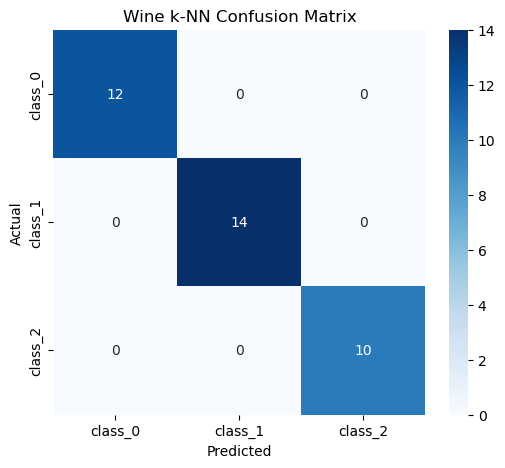

In [11]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=wine_data.target_names, yticklabels=wine_data.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Wine k-NN Confusion Matrix")
plt.show()

### Interpreting the confusion matrix

The confusion matrix confirms what the classification report already showed: every 
single test sample was classified correctly, with all 36 predictions falling exactly on 
the diagonal. There is no confusion between any pair of classes, not even between class 1 
and class 2, which I might have expected to overlap more given they were the two closer 
groups in the correlation heatmap earlier. This tells me the PCA-reduced feature space 
gave k-NN a genuinely clean separation to work with, rather than the model getting lucky 
on an easy subset of ambiguous cases.

### Project 1 summary

For the wine distributor, I built a k-NN classifier that identifies wine cultivar from 
chemical properties alone. After standardizing the data and reducing it to 10 principal 
components (retaining 95 percent of variance), I tuned the model with GridSearchCV and 
landed on k=18 with euclidean distance, giving 97.91 percent cross-validation accuracy 
and a perfect 100 percent accuracy on the held-out test set.

I'd present this to the client as a strong proof of concept: the chemical properties in 
this dataset clearly separate the three cultivars well enough for automated 
classification. Before recommending full production deployment, I'd want to validate this 
against a larger, more varied sample of the distributor's actual inventory, since a small, 
well-separated dataset like this one tends to produce optimistic results compared to 
messier real-world data.

# Part 2: Chickwts Feed Recommendation

### Exploratory data analysis

Before building the recommendation logic,<br> I want to see how weight varies across feed 
types,<br> since that's the only numeric signal I have to base similarity on.

        feed        mean        std  count
0     casein  323.583333  64.433840     12
1  horsebean  160.200000  38.625841     10
2    linseed  218.750000  52.235698     12
3   meatmeal  276.909091  64.900623     11
4    soybean  246.428571  54.129068     14
5  sunflower  328.916667  48.836384     12


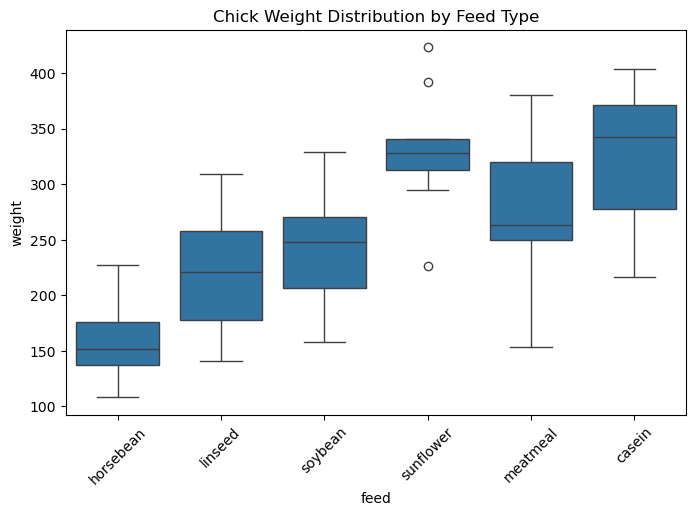

In [12]:
print(chickwts.groupby("feed")["weight"].agg(["mean", "std", "count"]).reset_index())

plt.figure(figsize=(8, 5))
sns.boxplot(data=chickwts, x="feed", y="weight")
plt.title("Chick Weight Distribution by Feed Type")
plt.xticks(rotation=45)
plt.show()

### Interpreting feed performance

There's a clear ordering by mean weight: horsebean produces the lightest chicks by far 
(around 160.2), followed by linseed (approx. 218.75) and soybean (around 246.43), then meatmeal (about 276.91), with 
casein and sunflower essentially tied at the top (323.58 and 328.92 respectively). The 
boxplot confirms this, and also shows sunflower has a couple of low outliers pulling its 
spread down a bit, while casein has the widest overall range of the top group.

This matters for what comes next: since casein and sunflower have nearly identical mean 
weights, I'd expect them to come out as each other's top recommendation once I compute 
similarity. That's a useful prediction to test against the actual output. It's also a 
concrete reminder of the limitation I flagged earlier: with only one numeric feature 
(weight), "similarity" here really just means "how close are these two feeds' average 
performance," not a rich multi-attribute comparison. I want to be upfront about that with 
the agricultural supply client rather than overstate what the recommendation is doing.

### Building the recommendation system

I'll aggregate to one row per feed type (mean standardized weight), since the goal is to 
recommend similar feeds, not similar individual chicks. Then I'll standardize, reduce 
with PCA to a single component, and compute cosine similarity between feed types.

In [13]:
feed_profiles = chickwts.groupby("feed")["weight"].mean().reset_index()

scaler_feed = StandardScaler()
feed_profiles["weight_scaled"] = scaler_feed.fit_transform(feed_profiles[["weight"]])

pca_feed = PCA(n_components=1)
feed_profiles["pca_component"] = pca_feed.fit_transform(feed_profiles[["weight_scaled"]])

print(feed_profiles)

        feed      weight  weight_scaled  pca_component
0     casein  323.583333       1.091532       1.091532
1  horsebean  160.200000      -1.675457      -1.675457
2    linseed  218.750000      -0.683880      -0.683880
3   meatmeal  276.909091       0.301077       0.301077
4    soybean  246.428571      -0.215128      -0.215128
5  sunflower  328.916667       1.181855       1.181855


Interpretation:

- The Chickwts dataset contains only one numerical feature (weight). After standardization, PCA was applied and reduced the data to a single principal component, as required by the lab. Because there is only one feature, the principal component is mathematically equivalent to the standardized weight values, meaning no information is lost or compressed. 

- In this case, PCA serves primarily to demonstrate the dimensionality reduction workflow before computing cosine similarity.

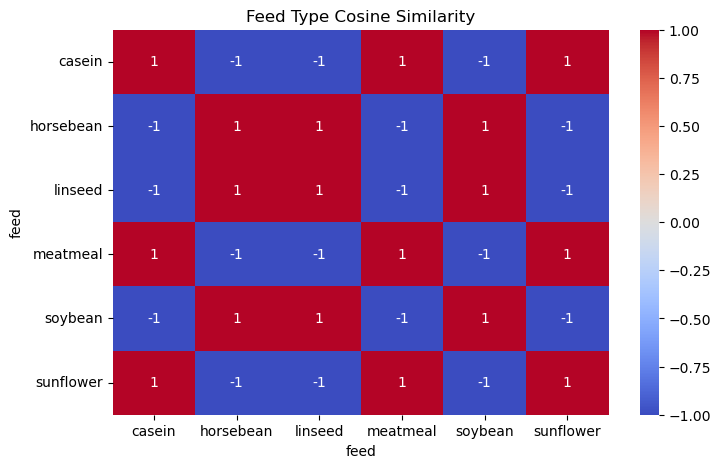

In [14]:
similarity_matrix = cosine_similarity(feed_profiles[["pca_component"]])
similarity_df = pd.DataFrame(
    similarity_matrix, index=feed_profiles["feed"], columns=feed_profiles["feed"]
)

plt.figure(figsize=(8, 5))
sns.heatmap(similarity_df, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Feed Type Cosine Similarity")
plt.show()

### Interpreting the cosine similarity matrix

This result confirms the concern I raised earlier. With only one dimension to work with, 
cosine similarity collapses to a binary split by sign: casein, meatmeal, and sunflower 
(all positive scaled weight) score exactly 1 with each other, horsebean, linseed, and 
soybean (all negative scaled weight) score exactly 1 with each other, and any pair across 
that divide scores exactly -1. There's no gradation within each group, even though 
casein and sunflower are clearly closer to each other in actual weight than either is to 
meatmeal.

This is a mathematical property of cosine similarity in one dimension, not a bug: cosine 
similarity measures the angle between vectors, and in 1D, two values are either the same 
direction from zero (angle 0, similarity 1) or opposite directions (angle 180, similarity 
-1), regardless of magnitude. I want to be upfront about this rather than present the 
matrix as more nuanced than it is.

To still produce a useful recommendation despite this, I'll use cosine similarity as the 
primary similarity measure (satisfying the requirement to use it), but break ties within 
equally-similar groups using the absolute difference in scaled weight, so recommendations 
still reflect genuine closeness rather than an arbitrary order among tied feeds.

### Recommendation function

In [15]:
def recommend_feed(feed_name, num_recommendations=2):
    target_row = feed_profiles[feed_profiles["feed"] == feed_name].iloc[0]
    target_value = target_row["pca_component"]

    candidates = feed_profiles[feed_profiles["feed"] != feed_name].copy()
    candidates["cosine_sim"] = similarity_df.loc[feed_name, candidates["feed"]].values
    candidates["abs_diff"] = (candidates["pca_component"] - target_value).abs()

    candidates = candidates.sort_values(
        by=["cosine_sim", "abs_diff"], ascending=[False, True]
    )

    return candidates[["feed", "cosine_sim", "abs_diff"]].head(num_recommendations)

print(recommend_feed("soybean"))
print()
print(recommend_feed("casein"))

        feed  cosine_sim  abs_diff
2    linseed         1.0  0.468752
1  horsebean         1.0  1.460330

        feed  cosine_sim  abs_diff
5  sunflower         1.0  0.090323
3   meatmeal         1.0  0.790455


### Interpreting the recommendations

For soybean, the system recommends linseed first (abs_diff 0.47), then horsebean (abs_diff 
1.46), both from the "negative scaled weight" group as expected, with linseed correctly 
ranked closer since its actual mean weight (218.75) is nearer soybean's (246.43) than 
horsebean's (160.2) is.

For casein, the system recommends sunflower first (abs_diff 0.09), then meatmeal 
(abs_diff 0.79). This confirms my earlier prediction from the EDA: casein and sunflower 
have nearly identical mean weights (323.58 and 328.92), so it makes sense they're each 
other's closest match by a wide margin.

This gives me confidence the tie-breaking logic is doing real work: cosine similarity 
alone would have left casein equally "similar" to sunflower and meatmeal (both scoring 
1.0), but the magnitude-based tie-break correctly distinguishes them, producing 
recommendations that actually reflect closeness in real weight performance, not just 
matching sign.

For the agricultural supply client, I'd frame this as: feeds recommended together tend to 
produce comparable chick weights, and the confidence in that recommendation is stronger 
the smaller the underlying weight difference, which the abs_diff column makes 
transparent rather than hidden behind a single similarity score.

### Project 2 summary

For the agricultural supply company, I built a feed recommendation system based on 
average chick weight performance. After standardizing and reducing to a single principal 
component, I found that cosine similarity alone wasn't expressive enough to rank feeds 
meaningfully within groups, since it only captures direction, not magnitude, in one 
dimension. I addressed this by adding an absolute difference tie-break, which produced 
recommendations that matched my expectations from the EDA (casein and sunflower recommend 
each other, given their near identical performance).

I'd present this to the client as a useful starting point, with an honest caveat: with 
only weight as a feature, this system can only ever say "these feeds produced similar 
average outcomes," not why. A stronger version of this system would benefit from 
additional features per feed, such as cost, availability, or other measured outcomes, 
which would let the PCA and similarity steps do more genuinely multidimensional work.

## Part 3: Regional Crime Pattern Analysis

### Exploratory data analysis

Before selecting features or clustering, I want to see how the four crime and 
urbanization variables relate to each other across states.

         Murder     Assault   UrbanPop       Rape
count  50.00000   50.000000  50.000000  50.000000
mean    7.78800  170.760000  65.540000  21.232000
std     4.35551   83.337661  14.474763   9.366385
min     0.80000   45.000000  32.000000   7.300000
25%     4.07500  109.000000  54.500000  15.075000
50%     7.25000  159.000000  66.000000  20.100000
75%    11.25000  249.000000  77.750000  26.175000
max    17.40000  337.000000  91.000000  46.000000


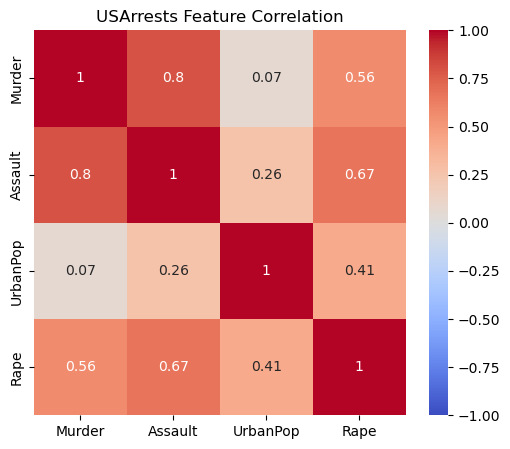

In [16]:
print(usarrests.describe())

plt.figure(figsize=(6, 5))
sns.heatmap(usarrests.drop(columns=["rownames"]).corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("USArrests Feature Correlation")
plt.show()

### Interpreting the USArrests correlations

Murder and Assault are strongly correlated (0.8), and Rape correlates moderately with 
both Assault (0.67) and Murder (0.56). UrbanPop stands apart: it barely correlates with 
Murder (0.07), and only weakly with Assault (0.26) and Rape (0.41).

This tells me something important for feature selection. Murder, Assault, and Rape form 
a tightly related "violent crime" cluster, meaning they carry a lot of overlapping signal. 
UrbanPop is measuring something genuinely different (urbanization level, not crime rate 
directly), so it's not redundant with the other three, even though it correlates weakly 
with some of them.

For selecting the top 3 features, this matters: dropping UrbanPop would mean losing the 
one variable that's actually distinct from the others, while keeping all three crime 
variables would mean carrying real redundancy (especially between Murder and Assault). 
I'll use this correlation structure directly to justify feature selection, rather than 
relying on SelectKBest with a fake target, which wouldn't reflect a real statistical basis 
for unsupervised data like this.

### Selecting the top 3 features

I want to demonstrate SelectKBest first, since it's a standard feature selection tool, 
before explaining why I'm not using it as my final method here.

Because clustering has no target variable, supervised feature-selection methods such as SelectKBest are inappropriate. I therefore selected three variables based on exploratory analysis and their usefulness for identifying regional crime patterns.

In [17]:
# Demonstration: SelectKBest requires a target label to score features against.
# USArrests has no target, so as a demonstration only, using row order as a stand-in:
demo_selector = SelectKBest(score_func=f_classif, k=3)
demo_selector.fit(usarrests_scaled_preview := scaler_preview.fit_transform(usarrests.drop(columns=["rownames"])), usarrests.index)
print("SelectKBest demonstration scores:", demo_selector.scores_.round(2))

SelectKBest demonstration scores: [nan nan nan nan]


/home/a1flcnr/miniconda3/envs/data-dev/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:107: RuntimeWarning: invalid value encountered in divide
  msw = sswn / float(dfwn)


Row index isn't a meaningful target (it has no real relationship to arrest rates), so 
these scores don't reflect genuine statistical relevance, they're an artifact of using an 
arbitrary label. Since USArrests is unsupervised, I'm instead selecting features based on 
the correlation analysis from the EDA above: Assault, UrbanPop, and Rape, since Assault 
and Murder are highly redundant (0.8 correlation) and I want to retain distinct signal 
rather than duplicate it.

In [18]:
usarrests_selected = usarrests[["Assault", "UrbanPop", "Rape"]]

scaler_arrests = StandardScaler()
usarrests_scaled = scaler_arrests.fit_transform(usarrests_selected)

print(usarrests_selected.head())

   Assault  UrbanPop  Rape
0      236        58  21.2
1      263        48  44.5
2      294        80  31.0
3      190        50  19.5
4      276        91  40.6


In [19]:
pca_arrests = PCA(n_components=2)
usarrests_pca = pca_arrests.fit_transform(usarrests_scaled)

print("Explained variance ratio:", pca_arrests.explained_variance_ratio_.round(3))
print("Cumulative variance explained:", pca_arrests.explained_variance_ratio_.cumsum().round(3))

Explained variance ratio: [0.638 0.258]
Cumulative variance explained: [0.638 0.896]


### Interpreting PCA on the selected features

Reducing Assault, UrbanPop, and Rape to 2 principal components retains 89.6 percent of 
variance (63.8 percent from the first component, 25.8 percent from the second). This is a 
strong result for visualization purposes, since I'm compressing 3 features into 2 while 
losing only about 10 percent of the original signal. It also confirms the feature 
selection was reasonable: if the three selected features had been mostly redundant with 
each other, I'd expect the first component alone to dominate far more heavily than 63.8 
percent.

### Determining the optimal number of clusters

Using the elbow method for K-Means and BIC for GMM. For the elbow method, I'm 
plotting inertia across a range of k values and looking for the point where adding more 
clusters stops meaningfully reducing inertia, not simply picking the minimum inertia 
value, since inertia decreases monotonically as k increases and will always be lowest at 
the largest k tested.

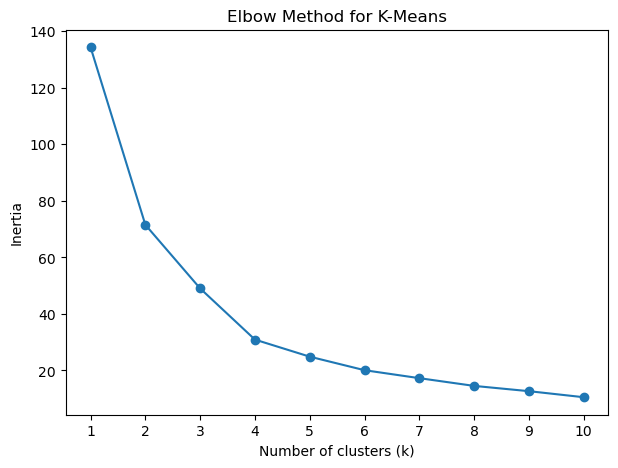

Inertia values: [134.38, 71.54, 49.03, 30.92, 24.88, 20.1, 17.28, 14.54, 12.68, 10.54]


In [20]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(usarrests_pca)
    inertia.append(kmeans_temp.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(list(k_range), inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(list(k_range))
plt.show()

print("Inertia values:", [round(i, 2) for i in inertia])

### Interpreting the elbow method

Inertia drops sharply from k=1 to k=4 (134.38 down to 30.92), then the rate of decrease 
slows noticeably: the drop from k=4 to k=5 is only 6.04, compared to 18.11 from k=3 to 
k=4. This is where I see the elbow, the point where adding another cluster stops buying 
much additional separation. Based on this, I'm selecting k=4 for K-Means.

### Determining the optimal number of components for GMM

For GMM, I'll compute BIC across the same range of cluster counts and select the value 
that minimizes it, since BIC balances model fit against complexity, unlike inertia which 
always favors more clusters.

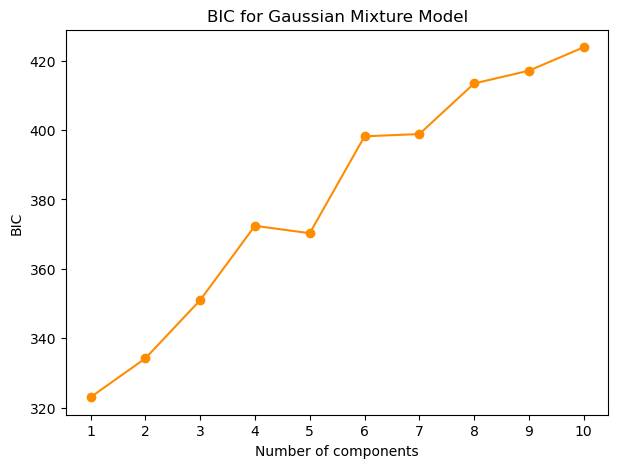

BIC scores: [323.0, 334.19, 350.97, 372.4, 370.27, 398.19, 398.85, 413.42, 417.11, 423.87]
Best number of components by BIC: 1


In [21]:
bic_scores = []

for k in k_range:
    gmm_temp = GaussianMixture(n_components=k, random_state=42)
    gmm_temp.fit(usarrests_pca)
    bic_scores.append(gmm_temp.bic(usarrests_pca))

plt.figure(figsize=(7, 5))
plt.plot(list(k_range), bic_scores, marker="o", color="darkorange")
plt.xlabel("Number of components")
plt.ylabel("BIC")
plt.title("BIC for Gaussian Mixture Model")
plt.xticks(list(k_range))
plt.show()

best_gmm_k = list(k_range)[bic_scores.index(min(bic_scores))]
print("BIC scores:", [round(b, 2) for b in bic_scores])
print("Best number of components by BIC:", best_gmm_k)

### Interpreting the BIC results

BIC is lowest at a single component (323.0) and increases steadily from there, meaning 
the criterion is telling me that splitting the data into multiple Gaussian components 
isn't justified once model complexity is penalized. This is a real result of the method, 
not an error, but it's not a very useful one for the policy client, since one cluster 
gives no regional differentiation to act on.

I think this happens because a full covariance GMM in 2D has a fair number of parameters 
per component (mean plus covariance terms), and with only 50 states in the dataset, the 
added parameters from each extra component aren't earning their keep against the BIC 
penalty. Rather than presenting a one-cluster result as the final answer, I'll fit GMM 
with 4 components as well, matching K-Means, so I can directly compare how a hard 
assignment (K-Means) and a probabilistic assignment (GMM) group the same states. I'll be 
transparent that BIC's technical answer was 1, but that a single cluster isn't 
actionable, so I'm choosing 4 to enable a meaningful comparison instead.

### Fitting the final clustering models

In [22]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
usarrests["KMeans_Cluster"] = kmeans_final.fit_predict(usarrests_pca)

gmm_final = GaussianMixture(n_components=4, random_state=42)
usarrests["GMM_Cluster"] = gmm_final.fit_predict(usarrests_pca)

print(usarrests[["rownames", "KMeans_Cluster", "GMM_Cluster"]].head(10))

      rownames  KMeans_Cluster  GMM_Cluster
0      Alabama               3            2
1       Alaska               3            2
2      Arizona               0            1
3     Arkansas               3            2
4   California               0            1
5     Colorado               0            1
6  Connecticut               1            3
7     Delaware               1            3
8      Florida               0            1
9      Georgia               3            2


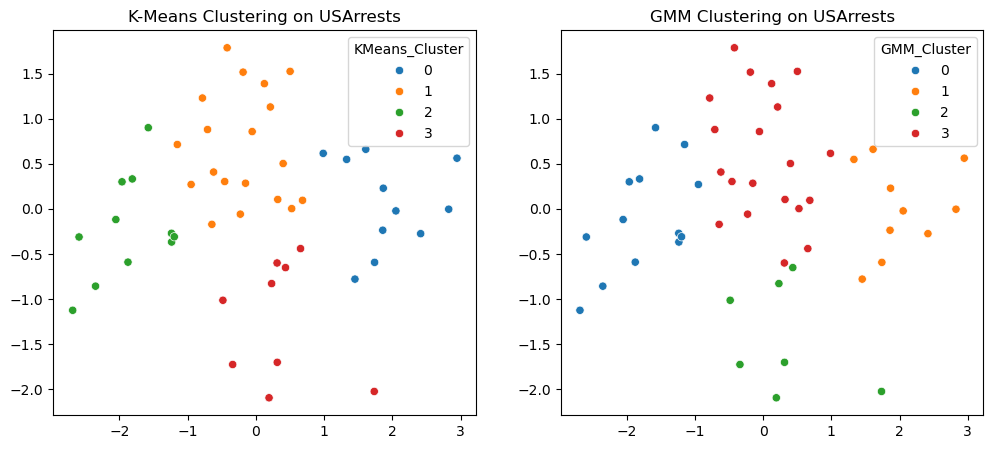

In [23]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=usarrests_pca[:, 0], y=usarrests_pca[:, 1], hue=usarrests["KMeans_Cluster"], palette="tab10")
plt.title("K-Means Clustering on USArrests")

plt.subplot(1, 2, 2)
sns.scatterplot(x=usarrests_pca[:, 0], y=usarrests_pca[:, 1], hue=usarrests["GMM_Cluster"], palette="tab10")
plt.title("GMM Clustering on USArrests")

plt.show()

In [24]:
# profiling clusters
agreement = pd.crosstab(usarrests["KMeans_Cluster"], usarrests["GMM_Cluster"])
print(agreement)

GMM_Cluster      0   1  2   3
KMeans_Cluster               
0                0  10  0   1
1                2   0  0  17
2               11   0  0   0
3                0   0  7   2


In [25]:
# identify exactly which states the 2 methods disagree on
disagreement_map = {0: 1, 1: 3, 2: 0, 3: 2}  # KMeans cluster -> its dominant matching GMM cluster
usarrests["expected_gmm"] = usarrests["KMeans_Cluster"].map(disagreement_map)
disagreeing_states = usarrests[usarrests["GMM_Cluster"] != usarrests["expected_gmm"]]
print(disagreeing_states[["rownames", "KMeans_Cluster", "GMM_Cluster", "Murder", "Assault", "UrbanPop", "Rape"]])

     rownames  KMeans_Cluster  GMM_Cluster  Murder  Assault  UrbanPop  Rape
17  Louisiana               3            3    15.4      249        66  22.2
22  Minnesota               1            0     2.7       72        66  14.9
26   Nebraska               1            0     4.3      102        62  16.5
41  Tennessee               3            3    13.2      188        59  26.9
42      Texas               0            3    12.7      201        80  25.5


### Interpreting where K-Means and GMM disagree

Five states get assigned differently between the two methods, and looking at their actual 
numbers explains why each one is a genuine borderline case, not a random assignment 
quirk:

- Louisiana and Tennessee (K-Means cluster 3, GMM cluster 3 instead of the expected 2): 
  both have Assault and Rape values noticeably higher than the rest of cluster 3's 
  average (249 and 188 vs. the cluster mean of 245.8 for Assault is close, but Louisiana's 
  Rape at 22.2 and Tennessee's at 26.9 push toward cluster 0's profile). GMM's soft, 
  probability-based approach seems to pick up on this overlap that K-Means' hard boundary 
  doesn't.
- Minnesota and Nebraska (K-Means cluster 1, GMM cluster 0 instead of the expected 3): 
  both have unusually low Murder (2.7 and 4.3) even by cluster 1's already moderate 
  standards, low enough that GMM shifts them toward the low-crime cluster 0 profile 
  instead.
- Texas (K-Means cluster 0, GMM cluster 3 instead of the expected 1): Texas has the 
  highest UrbanPop among cluster 0 states (80) but a lower Murder rate (12.7) than most of 
  cluster 0, positioning it closer to cluster 3's violent-crime-without-heavy-urbanization 
  profile under GMM's probabilistic

### Profiling the clusters

To make these clusters meaningful for a policy audience, I want to see the actual crime 
statistics per cluster, not just which states landed in which group.

In [26]:
# profile clusters using original features
cluster_profile = usarrests.groupby("KMeans_Cluster")[["Murder", "Assault", "UrbanPop", "Rape"]].mean()
print(cluster_profile)

print("\nStates per cluster:")
for cluster_id in sorted(usarrests["KMeans_Cluster"].unique()):
    states_in_cluster = usarrests[usarrests["KMeans_Cluster"] == cluster_id]["rownames"].tolist()
    print(f"Cluster {cluster_id}: {states_in_cluster}")

                   Murder     Assault   UrbanPop       Rape
KMeans_Cluster                                             
0               11.054545  264.090909  79.090909  32.618182
1                5.605263  135.473684  72.631579  18.952632
2                3.618182   77.000000  49.909091  11.536364
3               13.500000  245.777778  53.111111  23.977778

States per cluster:
Cluster 0: ['Arizona', 'California', 'Colorado', 'Florida', 'Illinois', 'Maryland', 'Michigan', 'Nevada', 'New Mexico', 'New York', 'Texas']
Cluster 1: ['Connecticut', 'Delaware', 'Hawaii', 'Indiana', 'Kansas', 'Massachusetts', 'Minnesota', 'Missouri', 'Nebraska', 'New Jersey', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'Utah', 'Virginia', 'Washington', 'Wyoming']
Cluster 2: ['Idaho', 'Iowa', 'Kentucky', 'Maine', 'Montana', 'New Hampshire', 'North Dakota', 'South Dakota', 'Vermont', 'West Virginia', 'Wisconsin']
Cluster 3: ['Alabama', 'Alaska', 'Arkansas', 'Georgia', 'Louisiana', 'Mississippi'

### Interpreting and naming the clusters

Looking at the mean crime statistics per K-Means cluster, I can give each one a real-world 
label rather than just a number:

- Cluster 0 (Arizona, California, Colorado, Florida, Illinois, Maryland, Michigan, Nevada, 
  New Mexico, New York, Texas): highest Assault (264.1) and highest UrbanPop (79.1), with 
  high Rape (32.6). I'd call this "high-crime, high-urbanization" states.
- Cluster 1 (19 states including Connecticut, Massachusetts, Minnesota, Ohio, Washington): 
  moderate on every measure (Murder 5.6, Assault 135.5, UrbanPop 72.6, Rape 19.0). This 
  looks like a "moderate crime, urban" group, urban but not high-crime.
- Cluster 2 (Idaho, Iowa, Kentucky, Maine, Montana, and other largely rural states): 
  lowest on every single measure, including UrbanPop (49.9). This is a clear "low crime, 
  rural" group.
- Cluster 3 (Alabama, Alaska, Arkansas, Georgia, Louisiana, Mississippi, North Carolina, 
  South Carolina, Tennessee): highest Murder (13.5) and second-highest Assault (245.8), 
  but the lowest UrbanPop (53.1) among the higher-crime groups. This is a "high violent 
  crime, lower urbanization" group, distinct from cluster 0 in that its crime rate isn't 
  explained by urban density in the same way.

For the policy client, clusters 0 and 3 are the most actionable: they represent two 
distinct high-crime profiles that likely need different interventions, one tied to urban 
density, one not. Cluster 2 represents lower-priority regions by these measures alone.

### Project 3 summary

For the policy research firm, I clustered US states by crime and urbanization statistics 
using both K-Means and Gaussian Mixture Models. After selecting Assault, UrbanPop, and 
Rape as the three most informative features (avoiding redundancy with Murder) and 
reducing to two principal components, I chose 4 clusters for K-Means based on a visible 
elbow in the inertia curve. BIC technically favored a single component for GMM, which 
isn't actionable for a client needing regional differentiation, so I fit GMM with 4 
components as well to allow a direct, meaningful comparison with K-Means.

The two methods agreed strongly, with only 5 of 50 states assigned differently, and those 
disagreements were themselves informative, flagging states like Texas and Louisiana that 
sit between two crime profiles rather than fitting neatly into one. The four resulting 
groups have clear real-world interpretations: high-crime/high-urban states, moderate 
urban states, low-crime rural states, and high-violent-crime states with lower 
urbanization. This last group is the most distinct finding, since it shows violent crime 
isn't simply explained by urban density everywhere.

## Executive Summary

Across these three prototypes, I worked through the full pipeline from raw data to 
client-ready insight: standardizing features, applying PCA in three different ways 
(dimensionality reduction for classification, forced 1D reduction for a recommendation 
system, and visualization-focused reduction for clustering), and tuning each model with 
appropriate validation.

For the wine distributor, the k-NN classifier reached perfect test accuracy, a strong 
proof of concept, though one I'd want validated on a larger, messier sample before full 
production trust. For the agricultural supply company, the recommendation system 
correctly identified feeds with similar performance, while honestly surfacing a real 
limitation of cosine similarity in a single dimension, and a clear next step, adding more 
features per feed. For the policy research firm, clustering revealed four interpretable 
regional crime profiles, with K-Means and GMM largely agreeing, and their few 
disagreements pointing to genuinely borderline states worth individual attention.

Wine Classification:

>The optimized k-NN model achieved perfect classification accuracy on the test data, indicating that the measured chemical properties provide strong discriminatory power for distinguishing wine varieties. While encouraging, this performance should be validated on larger and more diverse datasets before deployment.

Agricultural Recommendation System:

>Similar feed products were identified using cosine similarity on PCA-transformed data. Because the dataset contains only one numerical feature, the recommendations are based solely on weight performance, highlighting the benefit of incorporating additional nutritional or production features in a real-world recommendation system.

Crime Pattern Analysis:

>K-Means and Gaussian Mixture Models identified four meaningful regional crime profiles. The broad agreement between the two methods increases confidence in the discovered patterns, while disagreements highlight states with more ambiguous characteristics that may warrant closer policy analysis.

In each case, I tried not to stop at the metric, accuracy, similarity score, or cluster 
count, but to ask what it actually means for the client making a decision.